# 05 - Sensibilidad y Experimentacion Completa

Fase 4 del laboratorio semi-supervisado. Este notebook ejecuta:

- Experimento principal: 3 modelos x 3 fracciones x 5 seeds = 45 corridas.
- Sensibilidad GMM: covariance_type x reg_covar x 3 seeds = 36 corridas.
- Sensibilidad CKM: max_constraints x 3 seeds = 12 corridas.
- Comparacion train vs test para diagnosticar overfitting/underfitting.
- CSVs para visualizacion final y heatmaps de hiperparametros.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from experiments import load_dataset, run_experiment, run_grid_search, summarize_metrics
from models import ConstrainedKMeans, SemiSupervisedGMM, SupervisedBaseline

RESULTS_DIR = REPO_ROOT / 'results' / 'metrics'
FIGURES_DIR = REPO_ROOT / 'results' / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
print(f'Repo root: {REPO_ROOT}')
print(f'Results dir: {RESULTS_DIR}')


Repo root: /Users/retailcpu3/Documents/Lab10-MD
Results dir: /Users/retailcpu3/Documents/Lab10-MD/results/metrics


In [2]:
X, y, feature_names, class_names = load_dataset(REPO_ROOT)
print(f'X: {X.shape} | y: {y.shape}')
print(f'Features: {len(feature_names)}')
print(f'Classes: {class_names}')


X: (13543, 16) | y: (13543,)
Features: 16
Classes: {0: 'BARBUNYA', 1: 'BOMBAY', 2: 'CALI', 3: 'DERMASON', 4: 'HOROZ', 5: 'SEKER', 6: 'SIRA'}


## Configuracion experimental

Se usan las tres clases acordadas para Fase 4: baseline supervisado con GMM, GMM semi-supervisado y Constrained K-means. El `seed` controla tanto el split como la inicializacion del modelo.


In [3]:
LABEL_FRACTIONS = (0.05, 0.10, 0.20)
MAIN_SEEDS = 5
SENSITIVITY_SEEDS = 3

MAIN_MODELS = [
    (
        'SupervisedBaseline_GMM',
        lambda seed: SupervisedBaseline(
            n_components=7,
            covariance_type='full',
            max_iter=200,
            tol=1e-4,
            reg_covar=1e-3,
            n_estimators=100,
            random_state=seed,
        ),
    ),
    (
        'SemiSupervisedGMM',
        lambda seed: SemiSupervisedGMM(
            n_components=7,
            covariance_type='full',
            max_iter=100,
            tol=1e-4,
            reg_covar=1e-3,
            random_state=seed,
        ),
    ),
    (
        'ConstrainedKMeans',
        lambda seed: ConstrainedKMeans(
            n_clusters=7,
            max_iter=300,
            max_constraints=500,
            random_state=seed,
        ),
    ),
]


## Smoke test rapido

Antes de las corridas completas se valida una configuracion corta por modelo. Este bloque no reemplaza el experimento principal.


In [4]:
smoke_rows = []
for model_name, factory in MAIN_MODELS:
    df_smoke = run_experiment(
        factory,
        model_name,
        X,
        y,
        label_fractions=(0.10,),
        n_seeds=1,
        verbose=False,
    )
    smoke_rows.append(df_smoke)

df_phase4_smoke = pd.concat(smoke_rows, ignore_index=True)
df_phase4_smoke[['model', 'accuracy', 'train_accuracy', 'generalization_gap', 'error']]


,model,accuracy,train_accuracy,generalization_gap,error
0,SupervisedBaseline_GMM,0.842973,0.834599,-0.008374,None
1,SemiSupervisedGMM,0.890967,0.891983,0.001016,None
2,ConstrainedKMeans,0.791533,0.794831,0.003298,None


## Experimento principal

Este bloque produce `results/metrics/metrics_full.csv` con 45 filas: tres modelos, tres fracciones de etiquetas y cinco semillas.


In [5]:
full_runs = []
for model_name, factory in MAIN_MODELS:
    full_runs.append(
        run_experiment(
            factory,
            model_name,
            X,
            y,
            label_fractions=LABEL_FRACTIONS,
            n_seeds=MAIN_SEEDS,
            verbose=True,
        )
    )

df_metrics_full = pd.concat(full_runs, ignore_index=True)
metrics_full_path = RESULTS_DIR / 'metrics_full.csv'
df_metrics_full.to_csv(metrics_full_path, index=False)
print(f'Guardado: {metrics_full_path}')
print(f'Filas: {len(df_metrics_full)}')
df_metrics_full.head()


SupervisedBaseline_GMM:   0%|          | 0/15 [00:00<?, ?it/s]

SupervisedBaseline_GMM:   7%|▋         | 1/15 [00:00<00:04,  3.04it/s]

SupervisedBaseline_GMM:  13%|█▎        | 2/15 [00:00<00:04,  3.04it/s]

SupervisedBaseline_GMM:  20%|██        | 3/15 [00:00<00:03,  3.36it/s]

SupervisedBaseline_GMM:  27%|██▋       | 4/15 [00:01<00:03,  3.14it/s]

...

ConstrainedKMeans:  93%|█████████▎| 14/15 [00:14<00:01,  1.13s/it]

ConstrainedKMeans: 100%|██████████| 15/15 [00:15<00:00,  1.05it/s]

ConstrainedKMeans: 100%|██████████| 15/15 [00:15<00:00,  1.04s/it]

Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/metrics/metrics_full.csv
Filas: 45


,model,label_fraction,seed,accuracy,f1_macro,recall_macro,train_accuracy,train_f1_macro,train_recall_macro,generalization_gap,train_time_s,error
0,SupervisedBaseline_GMM,0.05,0,0.705390,0.707854,0.744487,0.712236,0.716002,0.751220,0.006846,0.297793,None
1,SupervisedBaseline_GMM,0.05,1,0.885060,0.892460,0.892053,0.874895,0.880817,0.878396,-0.010166,0.294741,None
2,SupervisedBaseline_GMM,0.05,2,0.777258,0.774536,0.777728,0.770042,0.764399,0.768085,-0.007216,0.225678,None
3,SupervisedBaseline_GMM,0.05,3,0.672163,0.597526,0.684782,0.671624,0.597950,0.683468,-0.000539,0.318273,None
4,SupervisedBaseline_GMM,0.05,4,0.856510,0.866915,0.866352,0.864557,0.875108,0.875587,0.008047,0.282055,None


In [6]:
summary_full = summarize_metrics(df_metrics_full, ['model', 'label_fraction']).round(4)
summary_full_path = RESULTS_DIR / 'metrics_full_summary.csv'
summary_full.to_csv(summary_full_path, index=False)
print(f'Guardado: {summary_full_path}')
summary_full


Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/metrics/metrics_full_summary.csv


,model,label_fraction,accuracy_mean,accuracy_std,f1_macro_mean,recall_macro_mean,train_accuracy_mean,gap_mean,train_time_s_mean,errors
0,ConstrainedKMeans,0.05,0.8073,0.0320,0.7982,0.8136,0.8076,0.0003,0.9696,0
1,ConstrainedKMeans,0.10,0.7957,0.0041,0.7830,0.8000,0.7943,-0.0013,1.0934,0
2,ConstrainedKMeans,0.20,0.8133,0.0286,0.8081,0.8208,0.8141,0.0008,0.9659,0
3,SemiSupervisedGMM,0.05,0.8918,0.0072,0.9125,0.9160,0.8889,-0.0029,0.2365,0
4,SemiSupervisedGMM,0.10,0.8952,0.0065,0.9153,0.9186,0.8925,-0.0026,0.1719,0
5,SemiSupervisedGMM,0.20,0.9010,0.0073,0.9187,0.9213,0.8989,-0.0020,0.2111,0
6,SupervisedBaseline_GMM,0.05,0.7793,0.0923,0.7679,0.7931,0.7787,-0.0006,0.2837,0
7,SupervisedBaseline_GMM,0.10,0.8262,0.0647,0.8383,0.8509,0.8232,-0.0031,0.3281,0
8,SupervisedBaseline_GMM,0.20,0.8002,0.0639,0.7791,0.8053,0.7995,-0.0007,0.4267,0


## Analisis de sensibilidad

Se fija `label_fraction=0.10`. Para GMM se varia `covariance_type` y `reg_covar`. Para CKM se varia `max_constraints`, interpretado como `max_ml=N` y `max_cl=N`.


In [7]:
GMM_GRID = {
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'reg_covar': [1e-6, 1e-4, 1e-2],
}

CKM_GRID = {
    'max_constraints': [50, 200, 500, 1000],
}

df_sens_gmm = run_grid_search(
    lambda seed, covariance_type, reg_covar: SemiSupervisedGMM(
        n_components=7,
        covariance_type=covariance_type,
        max_iter=100,
        tol=1e-4,
        reg_covar=reg_covar,
        random_state=seed,
    ),
    'SemiSupervisedGMM',
    GMM_GRID,
    X,
    y,
    label_fraction=0.10,
    n_seeds=SENSITIVITY_SEEDS,
    verbose=True,
)

df_sens_gmm.to_csv(RESULTS_DIR / 'sensitivity_gmm.csv', index=False)
print(f'GMM sensitivity rows: {len(df_sens_gmm)}')
df_sens_gmm.head()


SemiSupervisedGMM sensitivity:   0%|          | 0/36 [00:00<?, ?it/s]

SemiSupervisedGMM sensitivity:   3%|▎         | 1/36 [00:00<00:11,  3.15it/s]

SemiSupervisedGMM sensitivity:   6%|▌         | 2/36 [00:00<00:12,  2.73it/s]

SemiSupervisedGMM sensitivity:   8%|▊         | 3/36 [00:01<00:11,  2.85it/s]

SemiSupervisedGMM sensitivity:  11%|█         | 4/36 [00:01<00:09,  3.35it/s]

...

SemiSupervisedGMM sensitivity:  97%|█████████▋| 35/36 [00:09<00:00,  5.59it/s]

SemiSupervisedGMM sensitivity: 100%|██████████| 36/36 [00:10<00:00,  5.62it/s]

SemiSupervisedGMM sensitivity: 100%|██████████| 36/36 [00:10<00:00,  3.58it/s]

GMM sensitivity rows: 36


,model,label_fraction,seed,covariance_type,reg_covar,accuracy,f1_macro,recall_macro,train_accuracy,train_f1_macro,train_recall_macro,generalization_gap,train_time_s,error
0,SemiSupervisedGMM,0.1,0,full,0.000001,0.887029,0.904281,0.907474,0.891667,0.907289,0.909221,0.004637,0.281455,None
1,SemiSupervisedGMM,0.1,1,full,0.000001,0.892936,0.902930,0.905656,0.875105,0.889214,0.891941,-0.017831,0.365308,None
2,SemiSupervisedGMM,0.1,2,full,0.000001,0.896628,0.914395,0.918179,0.890612,0.906366,0.909383,-0.006016,0.293721,None
3,SemiSupervisedGMM,0.1,0,full,0.000100,0.890229,0.908430,0.911595,0.893565,0.909830,0.912322,0.003337,0.181656,None
4,SemiSupervisedGMM,0.1,1,full,0.000100,0.900566,0.912746,0.915241,0.885127,0.902439,0.905523,-0.015440,0.284394,None


In [8]:
df_sens_ckm = run_grid_search(
    lambda seed, max_constraints: ConstrainedKMeans(
        n_clusters=7,
        max_iter=300,
        max_constraints=max_constraints,
        random_state=seed,
    ),
    'ConstrainedKMeans',
    CKM_GRID,
    X,
    y,
    label_fraction=0.10,
    n_seeds=SENSITIVITY_SEEDS,
    verbose=True,
)

df_sens_ckm.to_csv(RESULTS_DIR / 'sensitivity_ckm.csv', index=False)
print(f'CKM sensitivity rows: {len(df_sens_ckm)}')
df_sens_ckm.head()


ConstrainedKMeans sensitivity:   0%|          | 0/12 [00:00<?, ?it/s]

ConstrainedKMeans sensitivity:   8%|▊         | 1/12 [00:00<00:10,  1.00it/s]

ConstrainedKMeans sensitivity:  17%|█▋        | 2/12 [00:01<00:08,  1.11it/s]

ConstrainedKMeans sensitivity:  25%|██▌       | 3/12 [00:02<00:08,  1.01it/s]

ConstrainedKMeans sensitivity:  33%|███▎      | 4/12 [00:03<00:07,  1.04it/s]

...

ConstrainedKMeans sensitivity:  92%|█████████▏| 11/12 [00:10<00:00,  1.06it/s]

ConstrainedKMeans sensitivity: 100%|██████████| 12/12 [00:11<00:00,  1.08s/it]

ConstrainedKMeans sensitivity: 100%|██████████| 12/12 [00:11<00:00,  1.00it/s]

CKM sensitivity rows: 12


,model,label_fraction,seed,max_constraints,accuracy,f1_macro,recall_macro,train_accuracy,train_f1_macro,train_recall_macro,generalization_gap,train_time_s,error
0,ConstrainedKMeans,0.1,0,50,0.797440,0.739441,0.779239,0.798523,0.739242,0.778647,0.001083,0.969534,None
1,ConstrainedKMeans,0.1,1,50,0.799409,0.739386,0.778216,0.795148,0.737884,0.777099,-0.004262,0.801003,None
2,ConstrainedKMeans,0.1,2,50,0.800640,0.741577,0.781151,0.796624,0.738141,0.777290,-0.004015,1.065084,None
3,ConstrainedKMeans,0.1,0,200,0.785873,0.765563,0.788584,0.788713,0.767879,0.790480,0.002841,0.889227,None
4,ConstrainedKMeans,0.1,1,200,0.795471,0.774916,0.796450,0.785654,0.769176,0.788347,-0.009817,0.756510,None


In [9]:
df_sensitivity = pd.concat([df_sens_gmm, df_sens_ckm], ignore_index=True, sort=False)
sensitivity_path = RESULTS_DIR / 'sensitivity.csv'
df_sensitivity.to_csv(sensitivity_path, index=False)
print(f'Guardado: {sensitivity_path}')
print(f'Filas: {len(df_sensitivity)}')

summary_sensitivity = summarize_metrics(
    df_sensitivity,
    ['model', 'covariance_type', 'reg_covar', 'max_constraints'],
)
summary_sensitivity_path = RESULTS_DIR / 'sensitivity_summary.csv'
summary_sensitivity.to_csv(summary_sensitivity_path, index=False)
print(f'Guardado: {summary_sensitivity_path}')
summary_sensitivity.round(4).head(20)


Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/metrics/sensitivity.csv
Filas: 48
Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/metrics/sensitivity_summary.csv


,model,covariance_type,reg_covar,max_constraints,accuracy_mean,accuracy_std,f1_macro_mean,recall_macro_mean,train_accuracy_mean,gap_mean,train_time_s_mean,errors
0,ConstrainedKMeans,NaN,NaN,50.0,0.7992,0.0016,0.7401,0.7795,0.7968,-0.0024,0.9452,0
1,ConstrainedKMeans,NaN,NaN,200.0,0.7913,0.0049,0.7714,0.7933,0.7864,-0.0049,0.9082,0
2,ConstrainedKMeans,NaN,NaN,500.0,0.7971,0.0049,0.7825,0.8004,0.7928,-0.0043,1.0112,0
3,ConstrainedKMeans,NaN,NaN,1000.0,0.7997,0.0039,0.7870,0.8036,0.7959,-0.0039,1.0154,0
4,SemiSupervisedGMM,diag,0.0000,NaN,0.8781,0.0042,0.8848,0.8887,0.8739,-0.0042,0.1872,0
5,SemiSupervisedGMM,diag,0.0001,NaN,0.8783,0.0038,0.8850,0.8889,0.8740,-0.0043,0.1825,0
6,SemiSupervisedGMM,diag,0.0100,NaN,0.8810,0.0049,0.8879,0.8906,0.8765,-0.0045,0.1383,0
7,SemiSupervisedGMM,full,0.0000,NaN,0.8922,0.0048,0.9072,0.9104,0.8858,-0.0064,0.3135,0
8,SemiSupervisedGMM,full,0.0001,NaN,0.8961,0.0053,0.9124,0.9151,0.8892,-0.0070,0.2502,0
9,SemiSupervisedGMM,full,0.0100,NaN,0.9092,0.0051,0.9224,0.9247,0.9051,-0.0041,0.3321,0


## Heatmaps y diagnostico train/test

Los heatmaps usan la media de accuracy sobre las semillas. El gap de generalizacion se calcula como `train_accuracy - accuracy`.


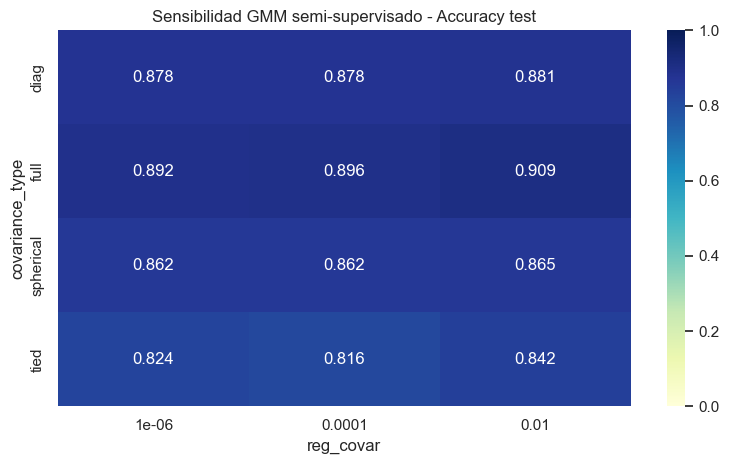

Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/figures/sensitivity_gmm_accuracy_heatmap.png


In [10]:
gmm_heat = (
    df_sens_gmm
    .groupby(['covariance_type', 'reg_covar'])['accuracy']
    .mean()
    .reset_index()
    .pivot(index='covariance_type', columns='reg_covar', values='accuracy')
)

plt.figure(figsize=(8, 4.8))
sns.heatmap(gmm_heat, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Sensibilidad GMM semi-supervisado - Accuracy test')
plt.xlabel('reg_covar')
plt.ylabel('covariance_type')
plt.tight_layout()
gmm_fig_path = FIGURES_DIR / 'sensitivity_gmm_accuracy_heatmap.png'
plt.savefig(gmm_fig_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Guardado: {gmm_fig_path}')


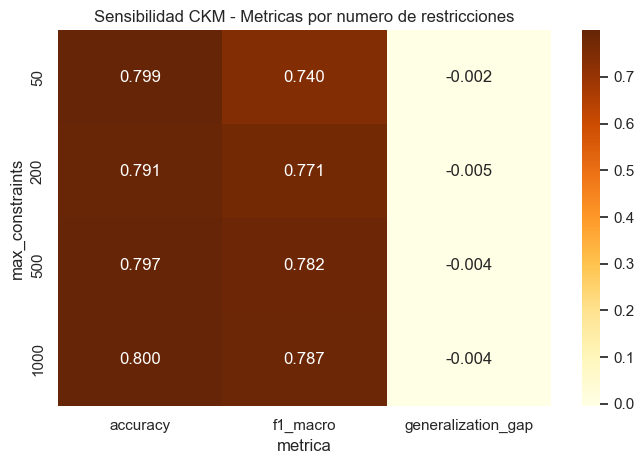

Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/figures/sensitivity_ckm_metrics_heatmap.png


In [11]:
ckm_heat = (
    df_sens_ckm
    .groupby('max_constraints')
    .agg(
        accuracy=('accuracy', 'mean'),
        f1_macro=('f1_macro', 'mean'),
        generalization_gap=('generalization_gap', 'mean'),
    )
)

plt.figure(figsize=(7, 4.8))
sns.heatmap(ckm_heat, annot=True, fmt='.3f', cmap='YlOrBr')
plt.title('Sensibilidad CKM - Metricas por numero de restricciones')
plt.xlabel('metrica')
plt.ylabel('max_constraints')
plt.tight_layout()
ckm_fig_path = FIGURES_DIR / 'sensitivity_ckm_metrics_heatmap.png'
plt.savefig(ckm_fig_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Guardado: {ckm_fig_path}')


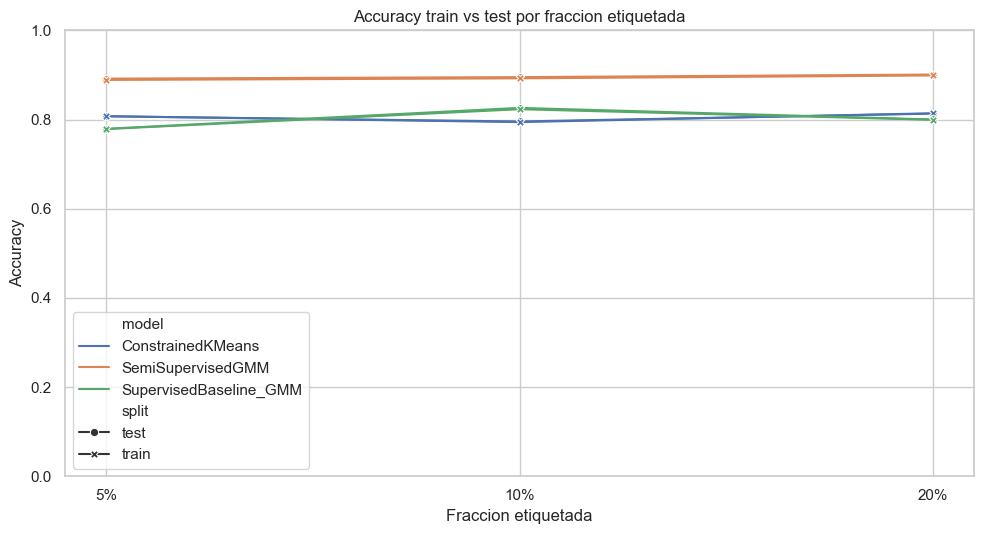

Guardado: /Users/retailcpu3/Documents/Lab10-MD/results/figures/phase4_train_test_accuracy.png


In [12]:
plot_df = summary_full.copy()
plot_df['label_fraction_pct'] = (plot_df['label_fraction'] * 100).astype(int).astype(str) + '%'
plot_long = plot_df.melt(
    id_vars=['model', 'label_fraction_pct'],
    value_vars=['accuracy_mean', 'train_accuracy_mean'],
    var_name='split',
    value_name='accuracy',
)
plot_long['split'] = plot_long['split'].map({
    'accuracy_mean': 'test',
    'train_accuracy_mean': 'train',
})

plt.figure(figsize=(10, 5.5))
sns.lineplot(
    data=plot_long,
    x='label_fraction_pct',
    y='accuracy',
    hue='model',
    style='split',
    markers=True,
    dashes=False,
)
plt.ylim(0, 1)
plt.title('Accuracy train vs test por fraccion etiquetada')
plt.xlabel('Fraccion etiquetada')
plt.ylabel('Accuracy')
plt.tight_layout()
gap_fig_path = FIGURES_DIR / 'phase4_train_test_accuracy.png'
plt.savefig(gap_fig_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Guardado: {gap_fig_path}')


## Validaciones finales

Las validaciones revisan que los CSVs tengan el tamano esperado y que no existan errores silenciosos.


In [13]:
assert len(df_metrics_full) == 45, f'metrics_full deberia tener 45 filas, tiene {len(df_metrics_full)}'
assert len(df_sensitivity) == 48, f'sensitivity deberia tener 48 filas, tiene {len(df_sensitivity)}'

metric_cols = [
    'accuracy', 'f1_macro', 'recall_macro',
    'train_accuracy', 'train_f1_macro', 'train_recall_macro',
    'generalization_gap', 'train_time_s',
]
assert df_metrics_full[metric_cols].notna().all().all(), 'Hay NaN en metrics_full'
assert df_sensitivity[metric_cols].notna().all().all(), 'Hay NaN en sensitivity'
assert df_metrics_full['error'].isna().all(), 'Hay errores en metrics_full'
assert df_sensitivity['error'].isna().all(), 'Hay errores en sensitivity'

print('Validaciones OK')
print(f'metrics_full rows: {len(df_metrics_full)}')
print(f'sensitivity rows: {len(df_sensitivity)}')


Validaciones OK
metrics_full rows: 45
sensitivity rows: 48
